In [5]:
# Import required libraries
import pandas as pd                  # For data loading and inspection
import matplotlib.pyplot as plt      # For creating plots
import seaborn as sns                # For statistical visualizations
from sklearn.datasets import load_iris  # To load the iris dataset

# Apply a clean visual style to all plots
sns.set_theme(style='whitegrid')

In [6]:
# Load the iris dataset from sklearn
iris = load_iris()

In [7]:
# Convert it into a pandas DataFrame (like an Excel table)
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width',
                                       'petal_length', 'petal_width'])

In [8]:
# Add the species column (as text labels)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [9]:
# Check the shape — how many rows and columns
print("Shape:", df.shape)

Shape: (150, 5)


In [10]:
# Check all column names
print("Columns:", df.columns.tolist())

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [11]:
# Preview first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
# Check data types of each column
print(df.dtypes)

sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object


In [13]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [14]:
# Statistical summary — mean, min, max, std of all columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [15]:
# Count how many flowers per species
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [20]:
# Mean value of each feature grouped by species
print(df.groupby('species', observed=True).mean().round(2))

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.43          1.46         0.25
versicolor          5.94         2.77          4.26         1.33
virginica           6.59         2.97          5.55         2.03


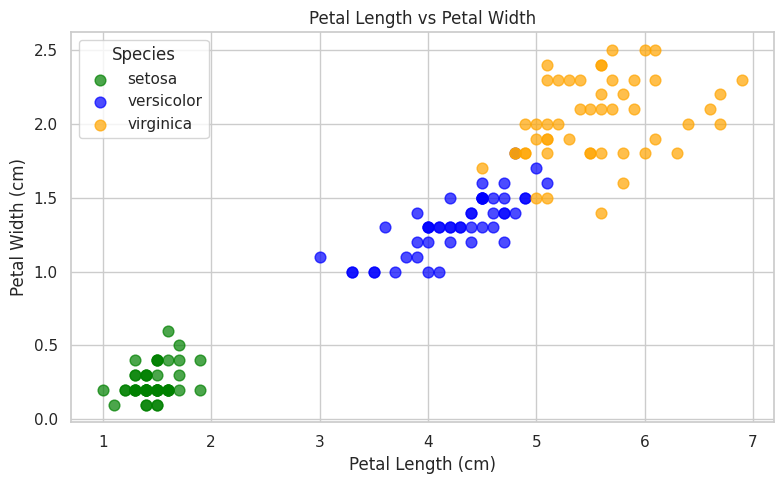

In [17]:
# Scatter plot — petal length vs petal width, colored by species
plt.figure(figsize=(8, 5))

for species, color in zip(df['species'].unique(), ['green', 'blue', 'orange']):
    subset = df[df['species'] == species]
    plt.scatter(subset['petal_length'], subset['petal_width'],
                label=species, color=color, alpha=0.7, s=60)

plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

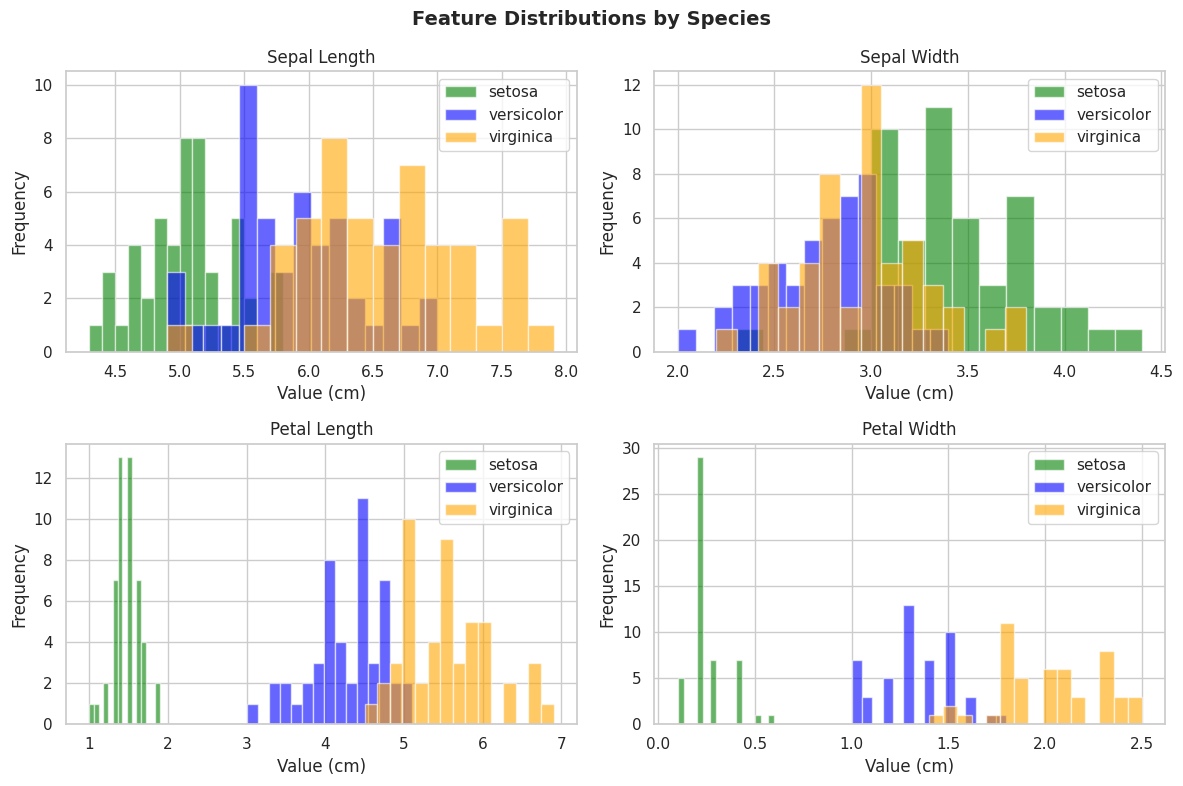

In [18]:
# Histogram — distribution of all 4 features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    for species, color in zip(df['species'].unique(), ['green', 'blue', 'orange']):
        subset = df[df['species'] == species]
        axes[i].hist(subset[feature], bins=15, alpha=0.6,
                     label=species, color=color, edgecolor='white')
    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].set_xlabel('Value (cm)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

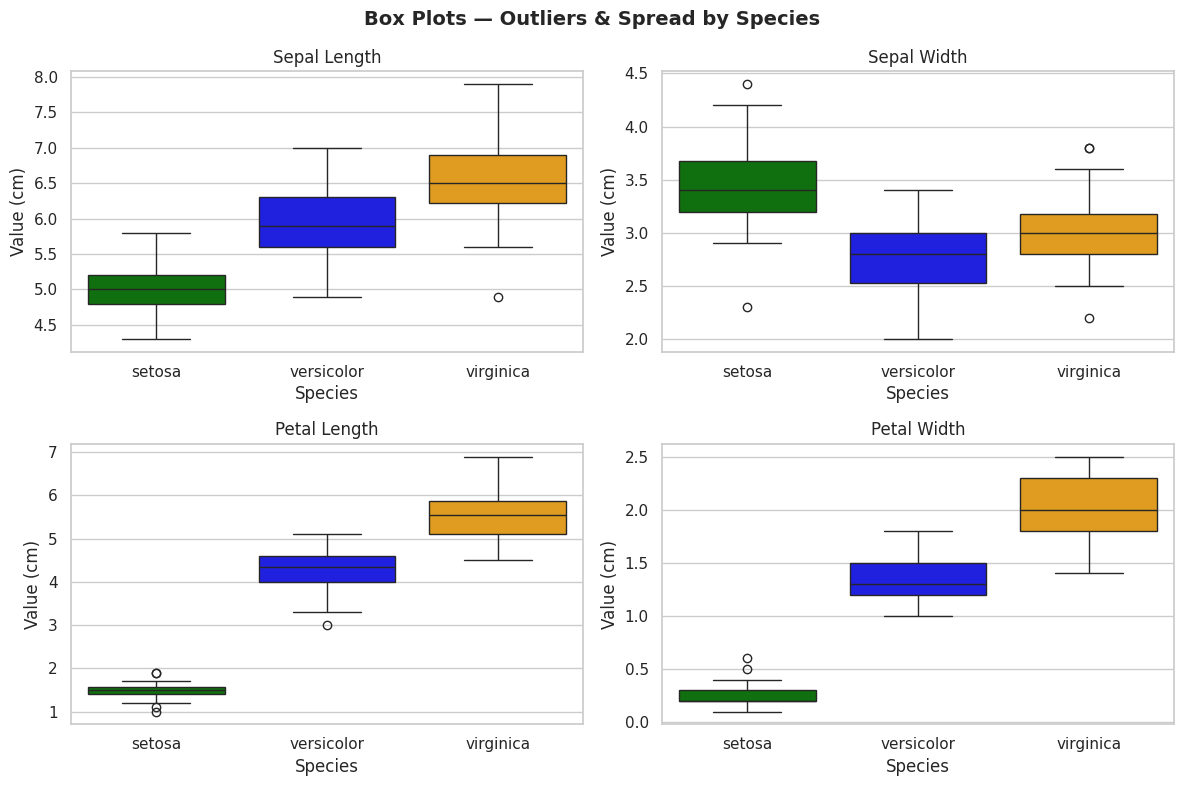

In [19]:
# Box plot — outliers and spread per species (fixed)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='species',
        y=feature,
        hue='species',          # ← fix: assign hue
        palette=['green', 'blue', 'orange'],
        legend=False,           # ← fix: hide duplicate legend
        ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel('Value (cm)')

plt.suptitle('Box Plots — Outliers & Spread by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()